In [3]:
import pandas as pd

file = '/Users/arghavan/lab/hp-results/hp-data.csv'

df = pd.read_csv(file, nrows=44)

df.columns

Index(['d(nm)', 'D (Å)', 'Volume (Å^3)', '#confined waters',
       '#waters between plates', 'N/Å^3', 'Enclosure Parameter',
       'N/V Ref. Bulk', '#neighbors', '#hbonds', '%hbond',
       'Average WW interaction energy', 'Average SW interaction energy',
       'Average Energy Per water (Kcal/mol)', 'Avg. Energy Ref. Bulk',
       'Delta E', 'Total Energy (Kcal/mol)',
       'Avg neighbor E (PAIRWISE) (Kcal/mol)',
       'Total Neighbor energy (Kcal/mol)', 'total entropy',
       'Entropy per water', 'Trans S', 'Rot S', 'Distance between 2 peaks',
       'Max 1st peak 1P', 'Max 2nd Peak 1P', 'First Min 1P', 'Max peak 1  2p',
       'Max peak 2 2p', 'Distance between peaks 2P'],
      dtype='object')

Text(0.5, 1.0, 'Number Density of Confined Waters vs. Plate Distance')

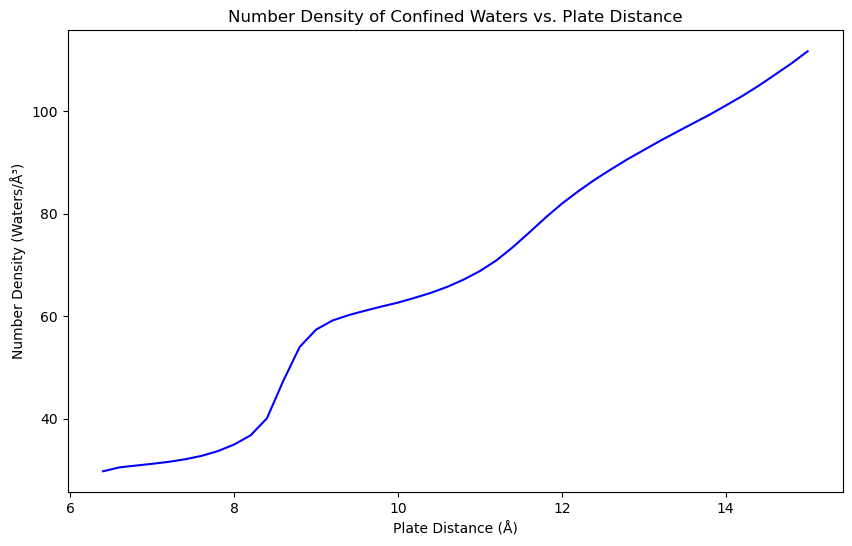

In [4]:
d_in_angstrom = df['D (Å)']
confined_volume = df.iloc[:, 2] #df['Volume (Å^3)']
no_wats = df['#confined waters']
# numDens = no_wats / confined_volume
# numDens


import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6))
plt.plot(d_in_angstrom, no_wats, linestyle='-', color='blue')
plt.xlabel('Plate Distance (Å)')
plt.ylabel('Number Density (Waters/Å³)')
plt.title('Number Density of Confined Waters vs. Plate Distance')

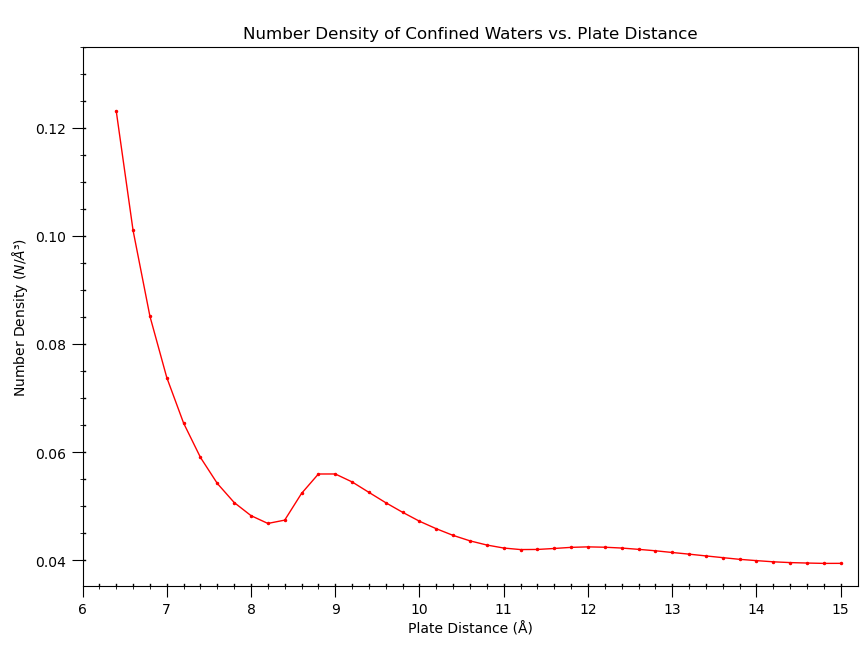

In [59]:
import matplotlib.ticker as ticker
import numpy as np
import os 

diff = no_wats - confined_volume
# diff
numDens = no_wats / confined_volume
plt.figure(figsize=(10,7))
plt.plot (d_in_angstrom, numDens, linestyle='-', color='red', marker = 'o', markersize = 1.5, linewidth = 1)

plt.xlim(6,15.2)

plt.title('\nNumber Density of Confined Waters vs. Plate Distance')
plt.xlabel('Plate Distance (Å)')
plt.ylabel(r'Number Density $(N/Å³)$')


plt.tick_params(axis='y', which='major', length=8)   
plt.tick_params(axis='y', which='minor', length=2)   
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.02))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.005))


plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(0.2))



medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)


medium_ticks = np.arange(0.04,0.14, 0.005)
plt.gca().set_yticks(medium_ticks, minor=True) 
for t in medium_ticks:
    plt.gca().axhline(t, xmin=0, xmax=0.003, color='k', lw=1)


output_path = '/Users/arghavan/lab/hp-results/number_of_waters/plots'
os.makedirs(output_path, exist_ok=True)
plt.savefig(f'{output_path}/number_density.png', dpi=800)


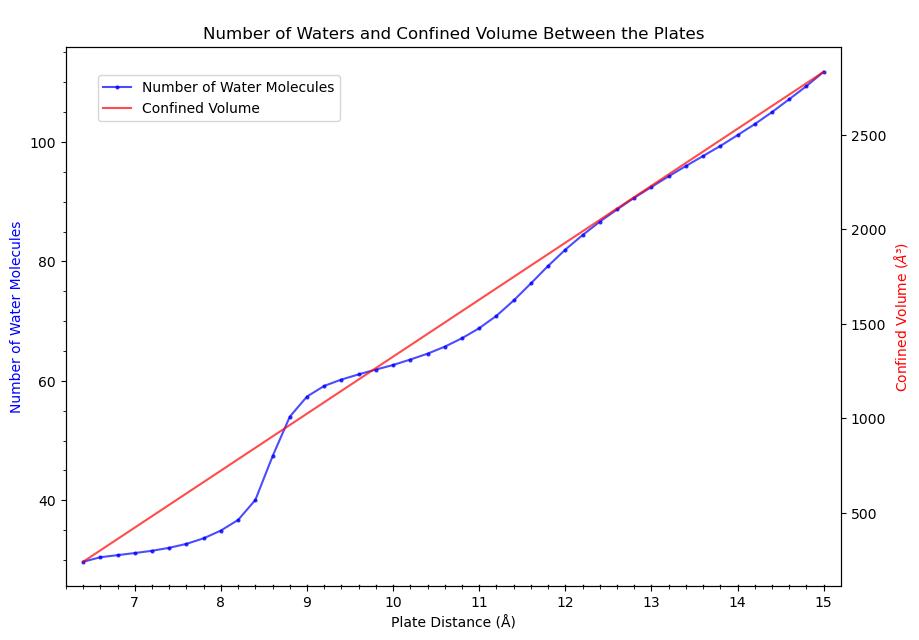

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import os 

fig, ax1 = plt.subplots(figsize=(10, 7))

ax1.plot(d_in_angstrom, no_wats, linestyle='-', color='blue', marker = 'o', markersize = 2, label='Number of Water Molecules', alpha=0.7, linewidth=1.5)
ax1.set_xlabel('Plate Distance (Å)')
ax1.set_ylabel('Number of Water Molecules', color='b')
# ax1.tick_params(axis='y', labelcolor='b')
plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(5))


ax2 = ax1.twinx()
ax2.plot(d_in_angstrom, confined_volume, 'r-', label='Confined Volume', alpha=0.7, linewidth=1.5)
ax2.set_ylabel(r'Confined Volume $(Å³)$', color='r')




fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85))
plt.xlim(6.2,15.2)
plt.title('\nNumber of Waters and Confined Volume Between the Plates')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))



medium_ticks = np.arange(6.2,15.2, 0.2)
plt.gca().set_xticks(medium_ticks, minor=True) 

# small_ticks = np.arange(6.2,15.2, 0.1)
# plt.gca().set_xticks(small_ticks, minor=True)

plt.tick_params(axis='x', which='major', length=8)   
plt.tick_params(axis='x', which='minor', length=2)   
for t in medium_ticks:
    plt.gca().axvline(t, ymin=0, ymax=0.003, color='k', lw=1)

output_path = '/Users/arghavan/lab/hp-results/number_of_waters/plots'
os.makedirs(output_path, exist_ok=True)
plt.savefig(f'{output_path}/number_of_waters_and_confined_volume.png', dpi=800)
